In [1]:
import pandas as pd
import os
from sqlalchemy import create_engine, text
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (15, 6)
sns.set_style('darkgrid')

In [2]:
DB_HOST = os.getenv("DB_HOST", "db")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "weather_db")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "postgres")

DATABASE_URL = (
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [3]:
engine = create_engine(DATABASE_URL)

In [4]:
with engine.connect() as conn:
    loc_df = pd.read_sql("select * from location", conn)
    weather_df = pd.read_sql("select * from weather_observation", conn)

In [5]:
weather_df.head()

,id,location_id,observed_at,temperature,feels_like,humidity,pressure,wind_speed,weather_description,weather_code,raw_json,created_at
0,f5e62e5d-0b08-45b7-af74-07630cd06955,1e25094b-b087-423c-8720-e0ad72456a54,2026-01-01 00:00:00+00:00,4.2,2.4,90.0,1008.7,1.1,None,3,None,2026-05-19 06:25:00.520258+00:00
1,0d8344ca-28e1-49b3-9591-eafc1468457b,1e25094b-b087-423c-8720-e0ad72456a54,2026-01-01 01:00:00+00:00,2.6,0.1,88.0,1007.8,3.9,None,45,None,2026-05-19 06:25:00.520258+00:00
2,cc0424b8-ec65-4aa5-aba1-7b8d15878d90,1e25094b-b087-423c-8720-e0ad72456a54,2026-01-01 02:00:00+00:00,2.8,0.7,90.0,1007.1,1.9,None,45,None,2026-05-19 06:25:00.520258+00:00
3,0c290096-d3b3-4f88-b4be-072423de9bb1,1e25094b-b087-423c-8720-e0ad72456a54,2026-01-01 03:00:00+00:00,3.1,1.2,94.0,1006.8,1.5,None,45,None,2026-05-19 06:25:00.520258+00:00
4,5396c401-1dd6-4029-9cae-78bce32b2857,1e25094b-b087-423c-8720-e0ad72456a54,2026-01-01 04:00:00+00:00,2.5,0.4,91.0,1006.4,1.8,None,45,None,2026-05-19 06:25:00.520258+00:00


In [6]:
df = loc_df.merge(weather_df, left_on='id', right_on='location_id', suffixes=['_loc', '_wea'])

In [7]:
seattle = df[df['city'] == 'Seattle']

In [8]:
seattle.shape

(2880, 19)

In [9]:
seattle.head()

,id_loc,city,state,country,latitude,longitude,created_at_loc,id_wea,location_id,observed_at,temperature,feels_like,humidity,pressure,wind_speed,weather_description,weather_code,raw_json,created_at_wea
0,1e25094b-b087-423c-8720-e0ad72456a54,Seattle,WA,USA,47.6062,-122.3321,2026-05-19 06:23:41.086791+00:00,f5e62e5d-0b08-45b7-af74-07630cd06955,1e25094b-b087-423c-8720-e0ad72456a54,2026-01-01 00:00:00+00:00,4.2,2.4,90.0,1008.7,1.1,None,3,None,2026-05-19 06:25:00.520258+00:00
1,1e25094b-b087-423c-8720-e0ad72456a54,Seattle,WA,USA,47.6062,-122.3321,2026-05-19 06:23:41.086791+00:00,0d8344ca-28e1-49b3-9591-eafc1468457b,1e25094b-b087-423c-8720-e0ad72456a54,2026-01-01 01:00:00+00:00,2.6,0.1,88.0,1007.8,3.9,None,45,None,2026-05-19 06:25:00.520258+00:00
2,1e25094b-b087-423c-8720-e0ad72456a54,Seattle,WA,USA,47.6062,-122.3321,2026-05-19 06:23:41.086791+00:00,cc0424b8-ec65-4aa5-aba1-7b8d15878d90,1e25094b-b087-423c-8720-e0ad72456a54,2026-01-01 02:00:00+00:00,2.8,0.7,90.0,1007.1,1.9,None,45,None,2026-05-19 06:25:00.520258+00:00
3,1e25094b-b087-423c-8720-e0ad72456a54,Seattle,WA,USA,47.6062,-122.3321,2026-05-19 06:23:41.086791+00:00,0c290096-d3b3-4f88-b4be-072423de9bb1,1e25094b-b087-423c-8720-e0ad72456a54,2026-01-01 03:00:00+00:00,3.1,1.2,94.0,1006.8,1.5,None,45,None,2026-05-19 06:25:00.520258+00:00
4,1e25094b-b087-423c-8720-e0ad72456a54,Seattle,WA,USA,47.6062,-122.3321,2026-05-19 06:23:41.086791+00:00,5396c401-1dd6-4029-9cae-78bce32b2857,1e25094b-b087-423c-8720-e0ad72456a54,2026-01-01 04:00:00+00:00,2.5,0.4,91.0,1006.4,1.8,None,45,None,2026-05-19 06:25:00.520258+00:00


In [10]:
seattle['observed_date'] = seattle['observed_at'].dt.strftime('%Y-%m-%d')

In [11]:
seattle.groupby("observed_date")[['temperature', 'feels_like']].mean()

,temperature,feels_like
observed_date,,
2026-01-01,2.495833,0.233333
2026-01-02,5.095833,3.208333
2026-01-03,8.145833,6.320833
2026-01-04,8.191667,5.745833
2026-01-05,5.829167,3.487500
...,...,...
2026-04-26,11.537500,9.012500
2026-04-27,11.679167,9.212500
2026-04-28,10.283333,8.095833


In [12]:
seattle['month'] = seattle['observed_at'].dt.month_name()

In [13]:
seattle_jan = seattle[seattle['month'] == 'January']

In [14]:
seattle_jan.head()

,id_loc,city,state,country,latitude,longitude,created_at_loc,id_wea,location_id,observed_at,...,feels_like,humidity,pressure,wind_speed,weather_description,weather_code,raw_json,created_at_wea,observed_date,month
0,1e25094b-b087-423c-8720-e0ad72456a54,Seattle,WA,USA,47.6062,-122.3321,2026-05-19 06:23:41.086791+00:00,f5e62e5d-0b08-45b7-af74-07630cd06955,1e25094b-b087-423c-8720-e0ad72456a54,2026-01-01 00:00:00+00:00,...,2.4,90.0,1008.7,1.1,None,3,None,2026-05-19 06:25:00.520258+00:00,2026-01-01,January
1,1e25094b-b087-423c-8720-e0ad72456a54,Seattle,WA,USA,47.6062,-122.3321,2026-05-19 06:23:41.086791+00:00,0d8344ca-28e1-49b3-9591-eafc1468457b,1e25094b-b087-423c-8720-e0ad72456a54,2026-01-01 01:00:00+00:00,...,0.1,88.0,1007.8,3.9,None,45,None,2026-05-19 06:25:00.520258+00:00,2026-01-01,January
2,1e25094b-b087-423c-8720-e0ad72456a54,Seattle,WA,USA,47.6062,-122.3321,2026-05-19 06:23:41.086791+00:00,cc0424b8-ec65-4aa5-aba1-7b8d15878d90,1e25094b-b087-423c-8720-e0ad72456a54,2026-01-01 02:00:00+00:00,...,0.7,90.0,1007.1,1.9,None,45,None,2026-05-19 06:25:00.520258+00:00,2026-01-01,January
3,1e25094b-b087-423c-8720-e0ad72456a54,Seattle,WA,USA,47.6062,-122.3321,2026-05-19 06:23:41.086791+00:00,0c290096-d3b3-4f88-b4be-072423de9bb1,1e25094b-b087-423c-8720-e0ad72456a54,2026-01-01 03:00:00+00:00,...,1.2,94.0,1006.8,1.5,None,45,None,2026-05-19 06:25:00.520258+00:00,2026-01-01,January
4,1e25094b-b087-423c-8720-e0ad72456a54,Seattle,WA,USA,47.6062,-122.3321,2026-05-19 06:23:41.086791+00:00,5396c401-1dd6-4029-9cae-78bce32b2857,1e25094b-b087-423c-8720-e0ad72456a54,2026-01-01 04:00:00+00:00,...,0.4,91.0,1006.4,1.8,None,45,None,2026-05-19 06:25:00.520258+00:00,2026-01-01,January


<Axes: xlabel='observed_at', ylabel='temperature'>

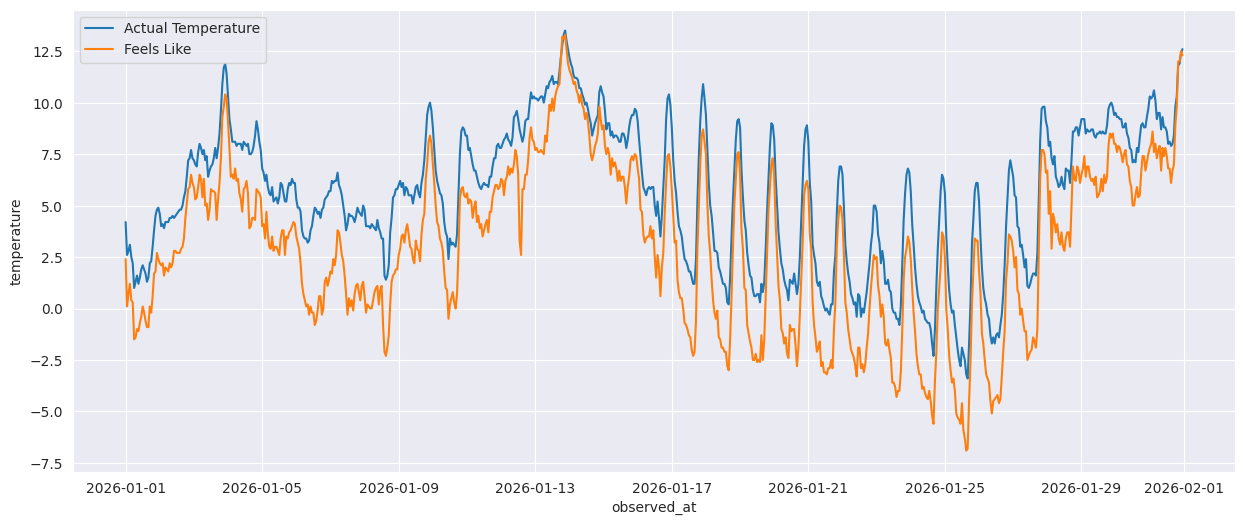

In [15]:
sns.lineplot(data=seattle_jan, x='observed_at', y='temperature', label='Actual Temperature')
sns.lineplot(data=seattle_jan, x='observed_at', y='feels_like', label='Feels Like')

In [16]:
def to_f(temp):
    return (temp * (9/5)) + 32

In [17]:
seattle_jan['temperature_f'] = seattle_jan['temperature'].apply(to_f)
seattle_jan['feels_like_f'] = seattle_jan['feels_like'].apply(to_f)

<Axes: xlabel='observed_at', ylabel='temperature_f'>

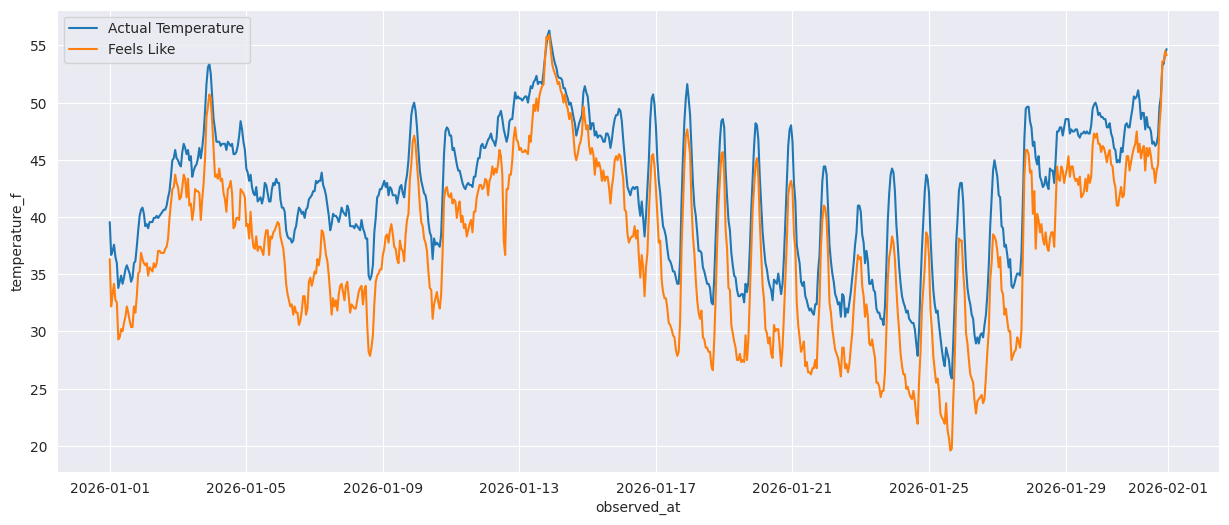

In [18]:
sns.lineplot(data=seattle_jan, x='observed_at', y='temperature_f', label='Actual Temperature')
sns.lineplot(data=seattle_jan, x='observed_at', y='feels_like_f', label='Feels Like')

In [19]:
seattle_jan_group = seattle_jan.groupby(['observed_date'])[['temperature', 'temperature_f', 'feels_like', 'feels_like_f', 'wind_speed']].mean().reset_index()

In [20]:
seattle_jan_group

,observed_date,temperature,temperature_f,feels_like,feels_like_f,wind_speed
0,2026-01-01,2.495833,36.4925,0.233333,32.4200,3.216667
1,2026-01-02,5.095833,41.1725,3.208333,37.7750,3.654167
2,2026-01-03,8.145833,46.6625,6.320833,43.3775,6.466667
3,2026-01-04,8.191667,46.7450,5.745833,42.3425,10.254167
4,2026-01-05,5.829167,42.4925,3.487500,38.2775,7.137500
5,2026-01-06,4.487500,40.0775,0.770833,33.3875,14.133333
6,2026-01-07,5.087500,41.1575,1.487500,34.6775,13.862500
7,2026-01-08,3.854167,38.9375,0.266667,32.4800,12.487500
8,2026-01-09,6.595833,43.8725,4.141667,39.4550,7.816667
9,2026-01-10,5.508333,41.9150,3.000000,37.4000,5.529167


In [21]:
seattle_jan_group['diff_t'] = seattle_jan_group['temperature_f'] - seattle_jan_group['feels_like_f']
seattle_jan_group['diff'] = seattle_jan_group['temperature'] - seattle_jan_group['feels_like']

In [22]:
seattle_jan_group['observed_date'] = pd.to_datetime(seattle_jan_group['observed_date'])

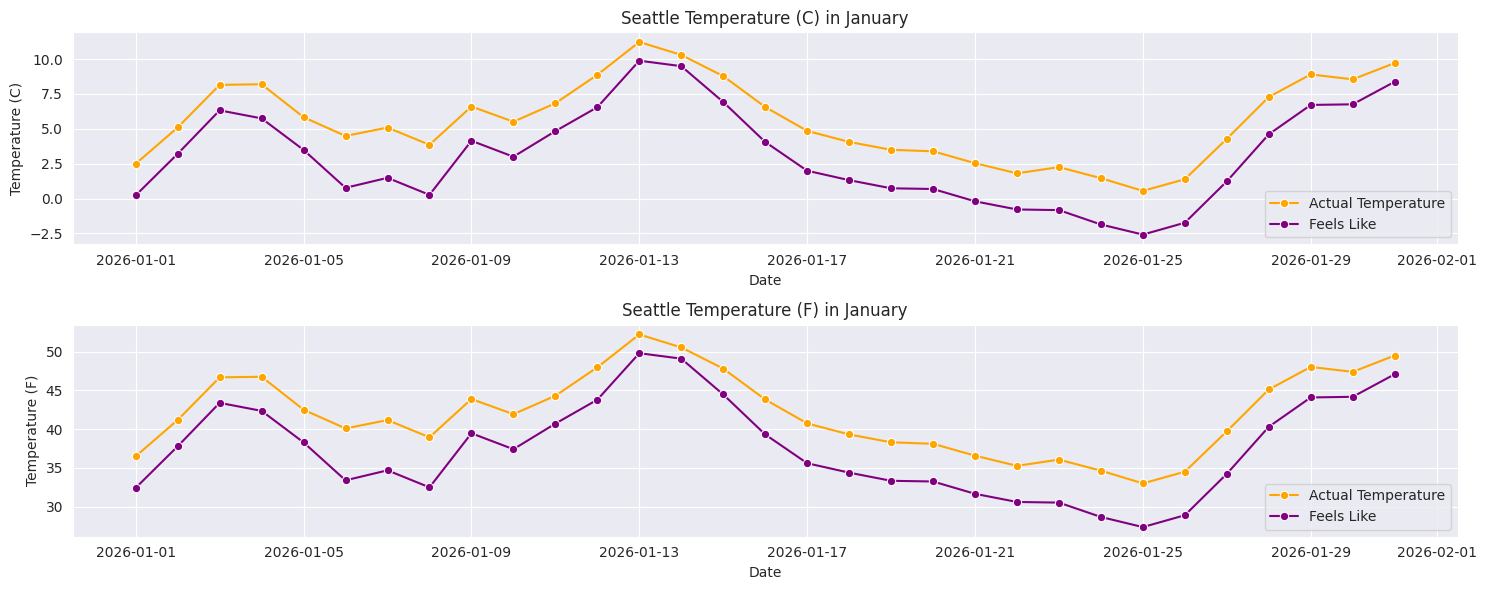

In [37]:
fig, ax = plt.subplots(2, 1)
sns.lineplot(data=seattle_jan_group, x='observed_date', y='temperature', label='Actual Temperature', marker='o', ax=ax[0], color='orange')
sns.lineplot(data=seattle_jan_group, x='observed_date', y='feels_like', label='Feels Like', marker='o', ax=ax[0], color='purple')

ax[0].set_title("Seattle Temperature (C) in January")
ax[0].set_xlabel("Date")
ax[0].set_ylabel("Temperature (C)")

sns.lineplot(data=seattle_jan_group, x='observed_date', y='temperature_f', label='Actual Temperature', marker='o', ax=ax[1], color='orange')
sns.lineplot(data=seattle_jan_group, x='observed_date', y='feels_like_f', label='Feels Like', marker='o', ax=ax[1] , color='purple')

ax[1].set_title("Seattle Temperature (F) in January")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Temperature (F)")

plt.tight_layout()

In [24]:
seattle_jan['observed_date'] = pd.to_datetime(seattle_jan['observed_date'])

In [25]:
seattle_jan.dtypes

id_loc                              object
city                                   str
state                                  str
country                                str
latitude                           float64
longitude                          float64
created_at_loc         datetime64[us, UTC]
id_wea                              object
location_id                         object
observed_at            datetime64[us, UTC]
temperature                        float64
feels_like                         float64
humidity                           float64
pressure                           float64
wind_speed                         float64
weather_description                 object
weather_code                         int64
raw_json                            object
created_at_wea         datetime64[us, UTC]
observed_date               datetime64[us]
month                                  str
temperature_f                      float64
feels_like_f                       float64
dtype: obje

<Axes: xlabel='observed_date', ylabel='wind_speed'>

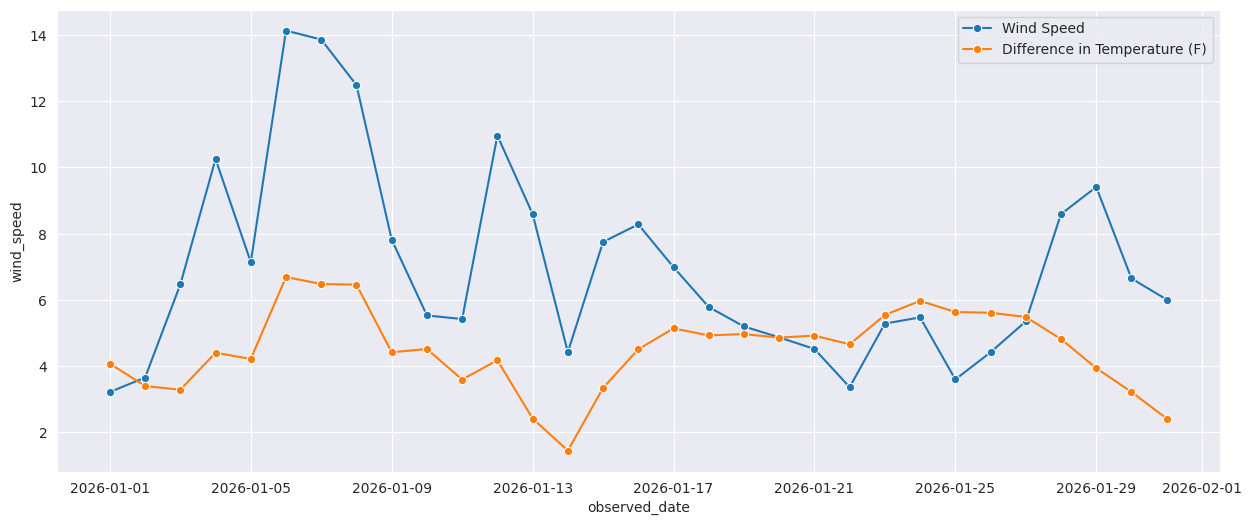

In [26]:
sns.lineplot(data=seattle_jan_group, x='observed_date', y='wind_speed', marker='o', label='Wind Speed')

sns.lineplot(data=seattle_jan_group, x='observed_date', y='diff_t', marker='o', label='Difference in Temperature (F)')

<Axes: xlabel='temperature', ylabel='feels_like'>

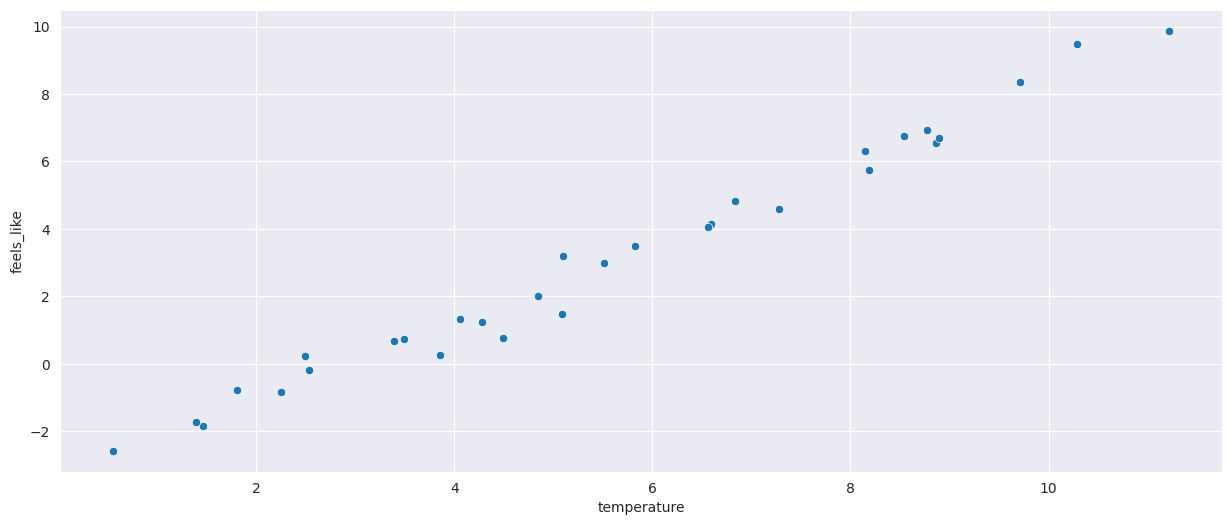

In [38]:
sns.scatterplot(data=seattle_jan_group, x='temperature', y='feels_like')

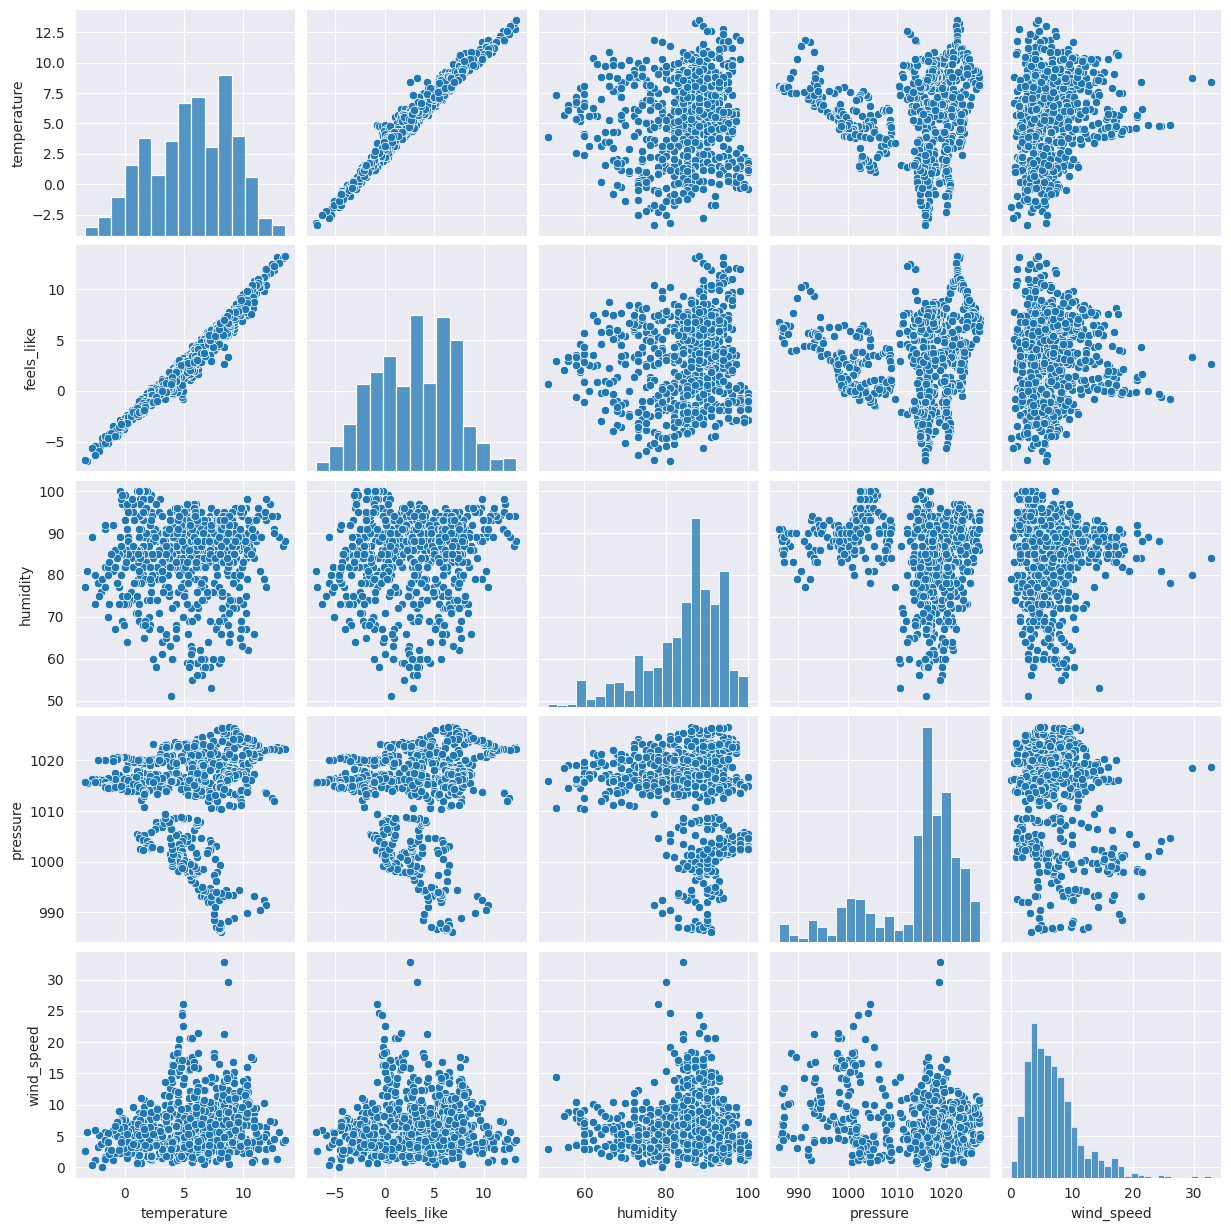

In [41]:
sns.pairplot(data=seattle_jan[['temperature', 'feels_like', 'humidity', 'pressure', 'wind_speed']])

In [40]:
seattle_jan.dtypes

id_loc                              object
city                                   str
state                                  str
country                                str
latitude                           float64
longitude                          float64
created_at_loc         datetime64[us, UTC]
id_wea                              object
location_id                         object
observed_at            datetime64[us, UTC]
temperature                        float64
feels_like                         float64
humidity                           float64
pressure                           float64
wind_speed                         float64
weather_description                 object
weather_code                         int64
raw_json                            object
created_at_wea         datetime64[us, UTC]
observed_date               datetime64[us]
month                                  str
temperature_f                      float64
feels_like_f                       float64
dtype: obje

In [45]:
corrs = seattle_jan[['temperature', 'feels_like', 'humidity', 'pressure', 'wind_speed']].corr()

<Axes: >

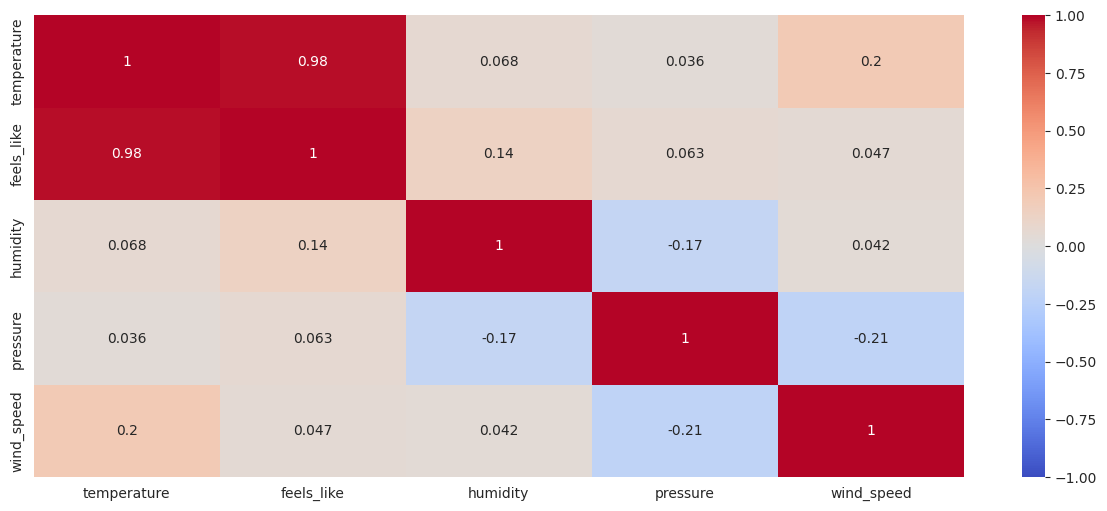

In [47]:
sns.heatmap(corrs, 
            vmin=-1,
           vmax=1,
           annot=True,
           cmap='coolwarm')